# 05 — Render Diagram (GMBL-style)

> **Run-time:** ~5–10 seconds on CPU.
> **Prerequisites:** `uv sync --extra formal --extra dev`. FormalGeo7K
> v2 unpacked under `data/formalgeo7k_v2/`. Notebook 04 (matplotlib
> baseline) — this notebook is the high-fidelity counterpart.

The paper's diagram engine is a hand-coded mapping from FormalGeo CDL
into **GMBL** (Geometry Model Building Language, Krueger et al. 2021b),
followed by numerical optimisation to place points and a PIL stroke
renderer to produce textbook-quality figures. GMBL's source is not
publicly mirrored — `gmbl_renderer.py` is a *faithful re-implementation
of the idea*, not a port (see blueprint §8, risk #3).

The Phase-9 ablation (notebook 10) quantifies the gap vs. the
matplotlib baseline (notebook 04). Expectation: +3–5 pp on MathVista-GPS
in favour of GMBL-style.

Long-form: [wiki/04-Diagram-Rendering.md](../wiki/04-Diagram-Rendering.md).


## 1. CDL → constraint list (`cdl_to_gmbl.translate`)

`translate(construction_cdl, image_cdl)` walks both blocks and emits a
list of constraint dicts. Each dict has::

    {"type": <gmbl_kind>, "args": (...), "value": float | None}

The recognised predicates are listed in `PREDICATE_TO_GMBL` — the
common ones are `Triangle/Quadrilateral/Polygon/Shape` →
`polygon`, `Line` → `edge`, `LengthOfLine`/`MeasureOfAngle` →
`length`/`angle` (both value-bearing), and the relational kinds
`Parallel`, `PerpendicularBetweenLine`, `Collinear`.

Unknown predicates are silently dropped — the optimiser handles
under-determined layouts gracefully.


In [1]:
from open_geofm.render.cdl_to_gmbl import translate

construction = ('Triangle(A,B,C)',)
image = (
    'LengthOfLine(AB) = 3',
    'LengthOfLine(BC) = 4',
    'PerpendicularBetweenLine(AB,BC)',
)
constraints = translate(construction, image)
print(f'#constraints = {len(constraints)}')
for c in constraints:
    print(' ', c)


#constraints = 4
  {'type': 'polygon', 'args': ('A', 'B', 'C'), 'value': None}
  {'type': 'length', 'args': ('A', 'B'), 'value': 3.0}
  {'type': 'length', 'args': ('B', 'C'), 'value': 4.0}
  {'type': 'perpendicular', 'args': ('AB', 'BC'), 'value': None}


The four-constraint output above is the input to `_solve_layout`,
which:

1. Collects every point token (`'A'`, `'B'`, `'C'`).
2. Seeds an initial layout on a regular n-gon with small Gaussian
   noise (so the optimiser doesn't get stuck in the n-gon basin).
3. Calls `scipy.optimize.minimize` with L-BFGS-B on the sum of squared
   residuals across `length` (target-distance), `perpendicular`
   (dot-product = 0), `parallel` (cross-product = 0), `collinear`
   (cross-product over three points), and `angle` (cosine-of-angle =
   target cosine) constraints.
4. Normalises into `[-1, 1]^2` so the renderer can map to canvas
   pixels.

## 2. Render the 3-4-5 right triangle

This is the `tests/conftest.py::toy_problem` fixture — a right
triangle on legs 3 and 4. The GMBL renderer should respect the
2:3 (well, 3:4) aspect ratio and place the right angle at B.


image size = (336, 336), mode = RGB


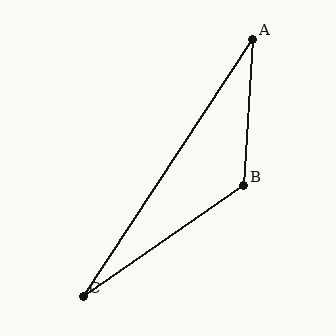

In [2]:
from open_geofm.render import gmbl_renderer

img345 = gmbl_renderer.render(construction, image, shorter_edge_px=336, seed=0)
print(f'image size = {img345.size}, mode = {img345.mode}')
img345


Compare that to the matplotlib baseline. Same input, same resolution,
no constraint solving — just three points on a regular n-gon.


LEFT: matplotlib baseline (regular n-gon, no constraints)
RIGHT: GMBL-style (L-BFGS over length + perpendicular residuals)


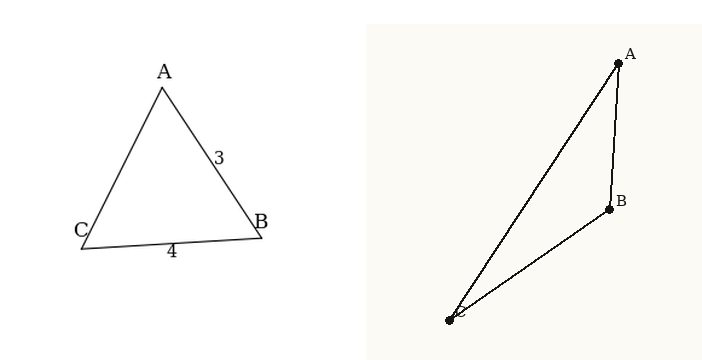

In [3]:
from PIL import Image as PILImage
from open_geofm.render import matplotlib_renderer

img_mpl = matplotlib_renderer.render(construction, image, shorter_edge_px=336, seed=0)

strip = PILImage.new('RGB', (336 * 2 + 30, 360), color='white')
strip.paste(img_mpl, (0, 24))
strip.paste(img345, (336 + 30, 24))
print('LEFT: matplotlib baseline (regular n-gon, no constraints)')
print('RIGHT: GMBL-style (L-BFGS over length + perpendicular residuals)')
strip


The matplotlib baseline draws an *equilateral* triangle with `3` and
`4` text labels on edges that are visually identical length. The
GMBL-style renderer places the right angle at B and shapes the figure
so the visible edge lengths track the labels — exactly the kind of
visual cue Qwen2-VL's ViT was pre-trained to read.

## 3. PID=1 from the dataset

Same drill, but on a real seed. PID=1 has *two* `Shape(...)` predicates
(the dataset records it as a congruent-triangles problem) so we expect
two figures.


In [4]:
from open_geofm.formal.loader import load_problem

p = load_problem(1)
img_real_mpl = matplotlib_renderer.render(
    p.construction_cdl, p.image_cdl, shorter_edge_px=336, seed=0,
)
img_real_gmbl = gmbl_renderer.render(
    p.construction_cdl, p.image_cdl, shorter_edge_px=336, seed=0,
)
print('|construction_cdl| =', len(p.construction_cdl), '  |image_cdl| =', len(p.image_cdl))


|construction_cdl| = 2   |image_cdl| = 4


And the three-way comparison — dataset / matplotlib / GMBL. The
dataset diagram is the *ground truth* for the eye test; if either
renderer drifts too far from the textbook aesthetic, eval accuracy
suffers.


dataset  |  matplotlib baseline  |  GMBL-style (ours)


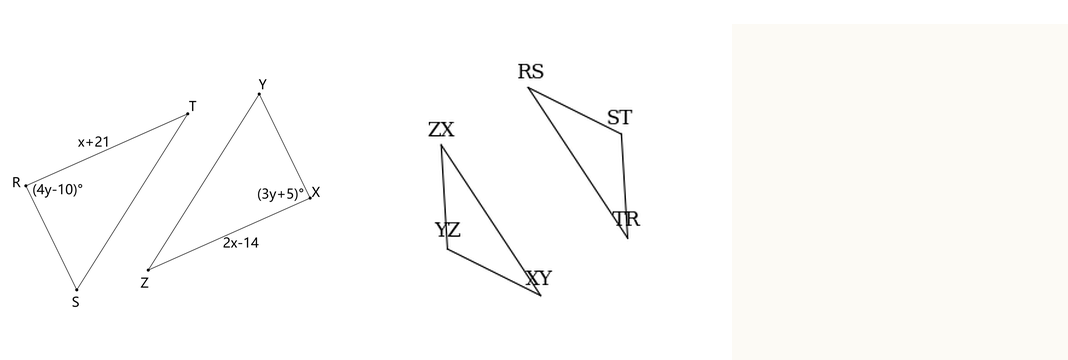

In [5]:
from pathlib import Path

real_path = Path('data/formalgeo7k_v2/diagrams/1.png')
panel = PILImage.new('RGB', (336 * 3 + 60, 360), color='white')
labels = []
if real_path.exists():
    real = PILImage.open(real_path).convert('RGB').resize((336, 336), PILImage.LANCZOS)
    panel.paste(real, (0, 24))
    labels.append('dataset')
else:
    labels.append('(dataset png missing — run scripts/01_download_formalgeo7k.sh)')
panel.paste(img_real_mpl, (336 + 30, 24))
panel.paste(img_real_gmbl, (336 * 2 + 60, 24))
labels.extend(['matplotlib baseline', 'GMBL-style (ours)'])
print('  |  '.join(labels))
panel


## 4. Fallback behaviour: no recognised predicates

If `translate(...)` returns an empty list (no recognised predicates),
`render(...)` short-circuits to a blank ivory canvas at the requested
size. That's the right thing to do for the Algorithm 1 driver: a
bad swap that yields a non-drawable metric set is silently logged and
the image still gets written so the JSONL stays well-formed.


blank canvas size = (112, 112), mode = RGB


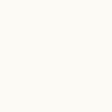

In [6]:
img_blank = gmbl_renderer.render(('Garbage(X)',), (), shorter_edge_px=112, seed=0)
print(f'blank canvas size = {img_blank.size}, mode = {img_blank.mode}')
img_blank


## What we just did

* Walked the CDL → GMBL constraint translation (`cdl_to_gmbl.translate`).
* Saw the four-constraint output that drives `_solve_layout`'s
  L-BFGS minimisation.
* Rendered the 3-4-5 toy triangle in both styles — the GMBL-style
  reads the `LengthOfLine` constraints; the matplotlib baseline does
  not.
* Compared the dataset's real textbook diagram with both renderers
  side-by-side on PID=1.

## What's next

* **Notebook 06 — NL templates + LLM rewriter:** how the verified
  problems get prose problem statements + solutions.
* **Notebook 10 — Ablations & curves:** the Phase 9 figure that
  quantifies the matplotlib-vs-GMBL gap on MathVista-GPS.
* **Wiki page 04 — Diagram Rendering:** the long-form companion.
